In [1]:
pip install readlif

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install matplotlib

In [ ]:
# Clone the repo if not already in Colab
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/NBCimageAnalysis'):
        !git clone https://github.com/FilLieb/NBCimageAnalysis.git
    os.chdir('/content/NBCimageAnalysis/learning/')
    print(os.listdir('.'))

In [ ]:
from readlif.reader import LifFile

# Open the .lif file
lif = LifFile('../data/lif/Project.lif')


Image001 Dims(x=1024, y=1024, z=1, t=1, m=1)
Dims(x=1024, y=1024, z=1, t=1, m=1)
(4.4, 4.4, None, None)
1
<PIL.Image.Image image mode=L size=1024x1024 at 0x2D1E500E850>


In [9]:
# List all images/series in the file
for img in lif.get_iter_image():
    print(img.name, img.dims)

Image001 Dims(x=1024, y=1024, z=1, t=1, m=1)


In [10]:
# Access a specific image by index
image = lif.get_image(0)

# Get image metadata
print(image.dims)        # (x, y, z, t, m) dimensions
print(image.scale)       # pixel scale (µm/pixel)
print(image.channels)    # number of channels

Dims(x=1024, y=1024, z=1, t=1, m=1)
(4.4, 4.4, None, None)
1


In [11]:
# Iterate over frames (returns PIL Images)
for frame in image.get_iter_t(c=0, z=0):
    print(frame)  # PIL Image object


<PIL.Image.Image image mode=L size=1024x1024 at 0x2D1EAD210F0>


In [12]:
# Convert a frame to a numpy array
import numpy as np
frame_array = np.array(frame)
frame_array.shape  # (height, width) for a single channel

(1024, 1024)

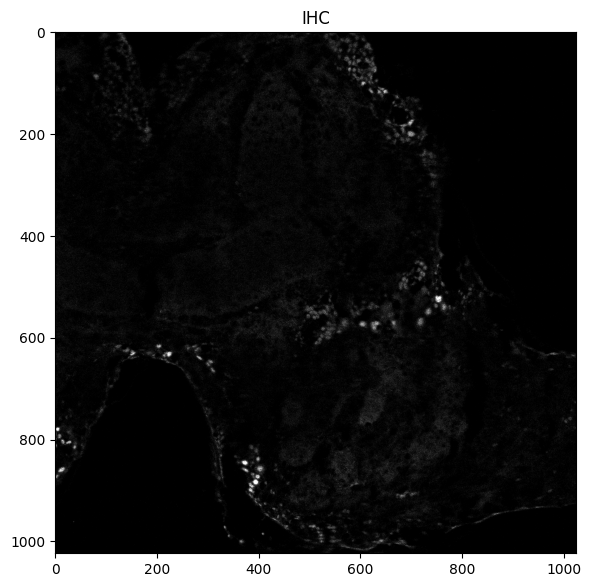

In [13]:
import matplotlib.pyplot as plt


# make a quick figure to display individual channels
plt.figure(figsize=(6, 6))
plt.imshow(frame_array, cmap='gray')
plt.title("IHC")
plt.tight_layout()
plt.show()